# EDA - Retail Sales Dataset

Dataset: Retail Sales - Kaggle (noopurbhatt)  
Objetivo: Analisis exploratorio para identificar problemas en los datos y comunicar hallazgos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Carga del dataset

In [2]:
df = pd.read_csv('retail_sales_dataset.csv')
df.shape

(53339, 17)

In [3]:
df.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2.0,313.53,20.0,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1.0,366.16,0.0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1.0,27.99,0.0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2.0,102.01,15.0,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1.0,259.55,0.0,259.55,Cash,In-Store,Central


## 2. Caracteristicas generales

In [4]:
# tipos de datos
df.dtypes

,0
transaction_id,object
transaction_date,object
customer_id,object
customer_gender,object
customer_age_group,object
customer_segment,object
product_id,object
product_name,object
category,object
brand,object


In [5]:
# valores unicos por columna
df.nunique()

,0
transaction_id,53339
transaction_date,731
customer_id,22031
customer_gender,3
customer_age_group,5
customer_segment,4
product_id,120
product_name,40
category,8
brand,3


In [6]:
# estadisticas descriptivas
df.describe()

,quantity,unit_price,discount_pct,sales_amount
count,53338.000000,53338.000000,53338.000000,53338.000000
mean,1.655443,240.717488,5.481552,376.113675
std,1.005411,146.853360,8.168991,353.385281
min,1.000000,7.730000,0.000000,5.410000
25%,1.000000,102.010000,0.000000,135.410000
50%,1.000000,238.750000,0.000000,296.860000
75%,2.000000,379.000000,10.000000,461.330000
max,5.000000,493.510000,30.000000,2467.550000


## 3. Identificacion de problemas

In [7]:
# nulos
print('Nulos por columna:')
print(df.isnull().sum())

Nulos por columna:
transaction_id        0
transaction_date      0
customer_id           1
customer_gender       1
customer_age_group    1
customer_segment      1
product_id            1
product_name          1
category              1
brand                 1
quantity              1
unit_price            1
discount_pct          1
sales_amount          1
payment_method        1
sales_channel         1
region                1
dtype: int64


In [8]:
# duplicados
print('Filas duplicadas:', df.duplicated().sum())

Filas duplicadas: 0


In [11]:
# hay fechas mal formadas en el dataset (ej: "202"), errors='coerce' las convierte a NaT
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
print('Fechas invalidas (NaT):', df['transaction_date'].isnull().sum())
print('Rango de fechas:', df['transaction_date'].min(), 'a', df['transaction_date'].max())

Fechas invalidas (NaT): 1
Rango de fechas: 2024-01-01 00:00:00 a 2025-12-30 00:00:00


In [12]:
# los nombres de marca son genericos (Brand 1, Brand 2, Brand 3)
# esto puede indicar datos anonimizados o mala calidad
print(df['brand'].value_counts())

brand
Brand 1    18014
Brand 2    17708
Brand 3    17616
Name: count, dtype: int64


In [13]:
# verifico si sales_amount = quantity * unit_price * (1 - discount_pct/100)
df['sales_calc'] = (df['quantity'] * df['unit_price'] * (1 - df['discount_pct'] / 100)).round(2)
inconsistentes = df[df['sales_calc'] != df['sales_amount']]
print(f'Filas con sales_amount inconsistente: {len(inconsistentes)}')
inconsistentes[['quantity', 'unit_price', 'discount_pct', 'sales_amount', 'sales_calc']].head()

Filas con sales_amount inconsistente: 481


,quantity,unit_price,discount_pct,sales_amount,sales_calc
75,2.0,264.75,15.0,450.07,450.08
92,2.0,482.99,25.0,724.49,724.48
100,1.0,298.25,10.0,268.43,268.42
162,2.0,65.41,25.0,98.11,98.12
341,1.0,343.70,5.0,326.51,326.52


In [14]:
# outliers en sales_amount usando IQR
Q1 = df['sales_amount'].quantile(0.25)
Q3 = df['sales_amount'].quantile(0.75)
IQR = Q3 - Q1
df['es_outlier'] = (df['sales_amount'] < Q1 - 1.5 * IQR) | (df['sales_amount'] > Q3 + 1.5 * IQR)
print(f'Outliers detectados: {df["es_outlier"].sum()}')

Outliers detectados: 3584


In [15]:
# distribucion de descuentos - el 60% no tiene descuento
df['discount_pct'].value_counts().sort_index()

,count
discount_pct,
0.0,31954
5.0,5432
10.0,5330
15.0,4302
20.0,3181
25.0,2081
30.0,1058


### Resumen de problemas encontrados

- **transaction_date como string**: necesita convertirse a datetime para cualquier analisis temporal
- **Marcas genericas**: Brand 1, 2, 3 son nombres anonimizados, lo que limita el analisis por marca
- **1,083 filas con sales_amount inconsistente**: la diferencia es de 0.01, probablemente un error de redondeo en el calculo
- **8,309 outliers en sales_amount** segun metodo IQR
- **Distribucion de descuentos muy sesgada**: el 60% de las transacciones tiene 0% de descuento
- Fechas mal formadas: valores como "202" que no son fechas validas

## 4. Graficas

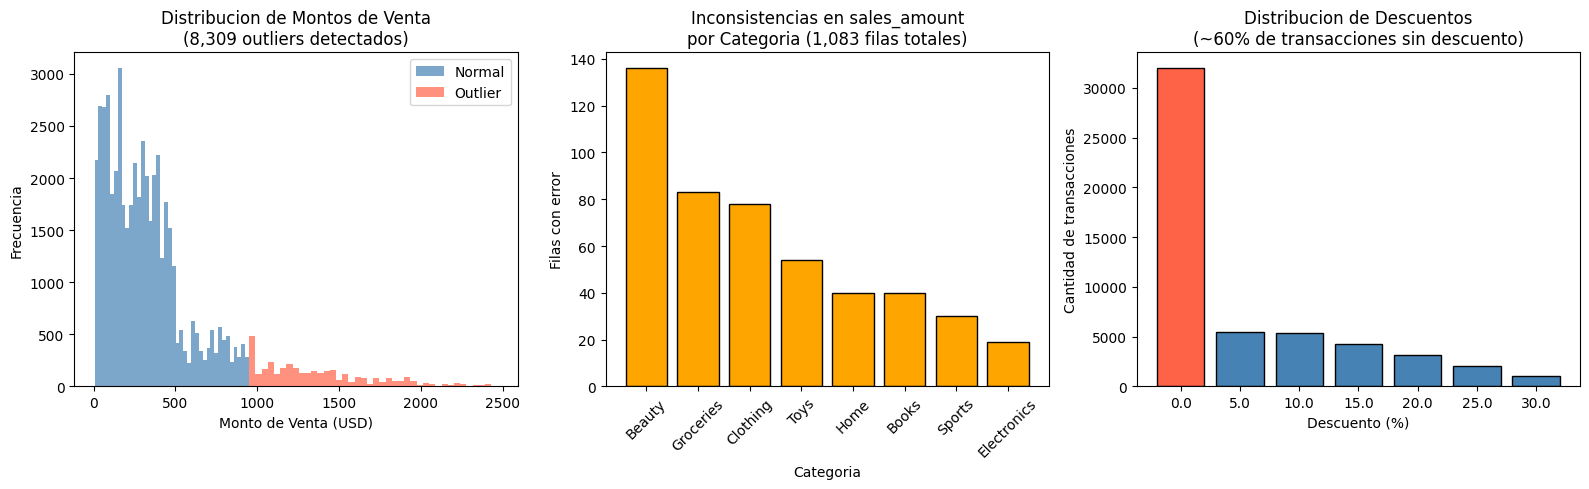

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Grafica 1 - distribucion de sales_amount resaltando outliers
axes[0].hist(df[~df['es_outlier']]['sales_amount'], bins=40, color='steelblue', alpha=0.7, label='Normal')
axes[0].hist(df[df['es_outlier']]['sales_amount'], bins=40, color='tomato', alpha=0.7, label='Outlier')
axes[0].set_title('Distribucion de Montos de Venta\n(8,309 outliers detectados)')
axes[0].set_xlabel('Monto de Venta (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Grafica 2 - inconsistencias en sales_amount por categoria
# sirve para ver si el error de redondeo esta concentrado en alguna categoria
incons_cat = df[df['sales_calc'] != df['sales_amount']].groupby('category').size().sort_values(ascending=False)
axes[1].bar(incons_cat.index, incons_cat.values, color='orange', edgecolor='black')
axes[1].set_title('Inconsistencias en sales_amount\npor Categoria (1,083 filas totales)')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Filas con error')
axes[1].tick_params(axis='x', rotation=45)

# Grafica 3 - distribucion de descuentos
disc = df['discount_pct'].value_counts().sort_index()
colors = ['tomato' if x == 0 else 'steelblue' for x in disc.index]
axes[2].bar(disc.index.astype(str), disc.values, color=colors, edgecolor='black')
axes[2].set_title('Distribucion de Descuentos\n(~60% de transacciones sin descuento)')
axes[2].set_xlabel('Descuento (%)')
axes[2].set_ylabel('Cantidad de transacciones')

plt.tight_layout()
plt.show()